In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [15]:
Y25 = pd.read_csv('../../data/M4_seismicanalysis_Yingxiang_Feb25.csv', dtype={'Gaia_source_ID_DR3':str})
pbjam = pd.read_csv('../../data/pbjam-results-dnu-numax-maddy-all.csv')
cross = pbjam.merge(Y25, on = 'star_id')
cross.columns

Index(['star_id', 'dnu_pbjam', 'ednu_pbjam', 'numax_pbjam', 'enumax_pbjam',
       'evol_stage', 'Gaia_source_ID_DR3', '2MASS_ID', 'Gmag', 'Quality_flag',
       'numax_pyMon', 'numax_err_pyMon', 'Teff_final', 'Teff_err_final',
       'Lum_bol', 'Lum_bol_err_random', 'Lum_bol_err_systematic', 'Mass',
       'Mass_err_rand', 'Delta_nu', 'delta_nu_02', 'epsilon'],
      dtype='object')

In [34]:
err_ratio_numax = np.sqrt(cross['numax_pyMon']**2/cross['numax_pbjam']**4*cross['enumax_pbjam']**2 + cross['numax_err_pyMon']**2/cross['numax_pbjam']**2)
err_ratio_dnu = cross['Delta_nu']**2/cross['dnu_pbjam']**4*cross['ednu_pbjam']


Text(0.5, 0, '$\\Delta \\nu_{\\mathrm{pbjam}}$ [$\\mu Hz$]')

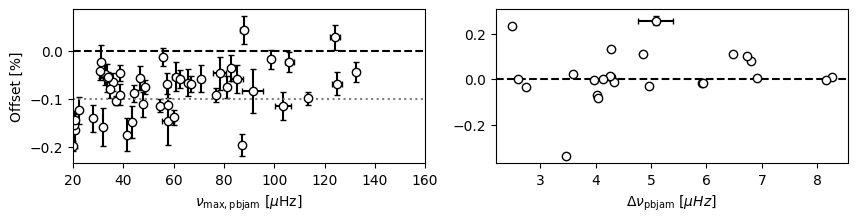

In [37]:
fig,axs = plt.subplots(figsize = (10, 2), nrows = 1, ncols = 2)
axs[0].errorbar(cross['numax_pbjam'], (cross['numax_pyMon'] - cross['numax_pbjam'])/cross['numax_pbjam'], yerr = err_ratio_numax,  xerr = cross['enumax_pbjam'], fmt = 'o', capsize = 2,  color = 'black', markeredgecolor = 'black', markerfacecolor = 'white')
#axs[0].errorbar(cross['numax_pbjam'], (cross['numax'] - cross['numax_pbjam'])/cross['numax_pbjam'], xerr  = cross['enumax_pbjam'], fmt = '^', markeredgecolor = 'black', capsize = 2, color = 'black',)
#plt.plot(np.linspace(20, 160), np.linspace(20, 160), color = 'black', linestyle = '--')
axs[0].axhline(0, color = 'black', linestyle = '--')
axs[0].axhline(-0.1, color = 'gray', linestyle = 'dotted')
axs[0].set_xlim(20, 160)
#ax.set_ylim(20, 160)
axs[0].set_xlabel(r'$\nu_{\mathrm{max, pbjam}}$ [$\mu$Hz]')
axs[0].set_ylabel(r'Offset [%]')
axs[1].errorbar(cross['dnu_pbjam'], (cross['Delta_nu'] -cross['dnu_pbjam'])/cross['dnu_pbjam'], yerr = err_ratio_dnu, xerr  = cross['ednu_pbjam'], fmt = 'o', capsize = 2, color = 'black', markerfacecolor = 'white')
axs[1].axhline(0, color = 'black', linestyle = '--')
axs[1].set_xlabel(r'$\Delta \nu_{\mathrm{pbjam}}$ [$\mu Hz$]')
#fig.savefig('../../figs/numax-dnu-pbjam-vs-M22-Y25.png', bbox_inches = 'tight', dpi = 150)

In [22]:
T22 = pd.read_csv('../../data/Tailo_2022_processed.csv', dtype={'Gaia_source_ID_DR3':str})
M22 = pd.read_csv('../../data/M4RGB_ps/M4_seismicanalysis.csv', dtype={'Gaia_source_ID_DR3':str})
IDs = M22[['star_id', 'Gaia_source_ID_DR3']]
Y25 = Y25.drop('Gaia_source_ID_DR3', axis = 1)
Y25_ = Y25.merge(IDs, on = 'star_id')
YT = T22.merge(Y25_, on = 'Gaia_source_ID_DR3')
YT

,LPhot,eLPhot,Teff,numax,enumax,dnu,ednu,WID,POPCUBI,Gaia_source_ID_DR3,...,Teff_final,Teff_err_final,Lum_bol,Lum_bol_err_random,Lum_bol_err_systematic,Mass,Mass_err_rand,Delta_nu,delta_nu_02,epsilon
0,37.865,4.083,4788.0,38.724,0.965,4.616,0.180,W491,2G,6045479078332149632,...,4892,61.000000,32.91,0.61,3.82,0.76,0.04,NaN,NaN,NaN
1,21.765,2.192,4926.0,75.929,2.367,7.613,0.231,W508,2G,6045478047540140544,...,4988,74.000000,22.52,0.44,2.62,0.91,0.05,NaN,NaN,NaN
2,71.180,7.748,4668.0,18.148,1.024,2.558,0.081,W760 ( * ),2G,6045477841381440384,...,4865,51.000000,65.23,1.06,7.57,0.67,0.04,NaN,NaN,NaN
3,28.142,3.030,4844.0,53.392,2.258,6.056,0.171,W779,1G,6045479490649030272,...,4836,73.000000,25.64,0.60,2.98,0.83,0.05,NaN,NaN,NaN
4,12.892,1.235,5030.0,123.780,3.537,11.765,0.309,W837,2G,6045478081899629696,...,5157,108.001212,12.97,0.29,1.51,0.79,0.06,NaN,NaN,NaN
5,21.934,2.229,4900.0,71.632,2.839,7.449,0.301,W1068,2G,6045478184978847616,...,5026,65.000000,20.37,0.34,2.37,0.80,0.04,NaN,NaN,NaN
6,48.529,5.227,4787.0,31.402,1.722,3.899,0.296,W1091,2G,6045478666015246592,...,4810,108.001212,44.00,1.53,5.11,0.84,0.07,3.75,NaN,0.60
7,28.109,3.026,4858.0,50.740,0.995,5.375,0.272,W1156,1G,6045477910100876544,...,4785,61.000000,28.35,0.60,3.29,0.92,0.05,5.84,0.17,1.23
8,22.325,2.271,4885.0,72.196,2.312,7.132,0.440,W1582,1G,6045477944460600960,...,4954,108.001212,20.95,0.60,2.43,0.81,0.06,NaN,NaN,NaN
9,20.374,2.016,4966.0,83.731,1.718,8.619,0.680,W1717,2G,6045478730423545984,...,5035,72.000000,18.04,0.33,2.10,0.76,0.04,NaN,NaN,NaN


In [23]:
err_ratio_dnu = YT['Delta_nu']**2/YT['dnu']**4*YT['ednu']

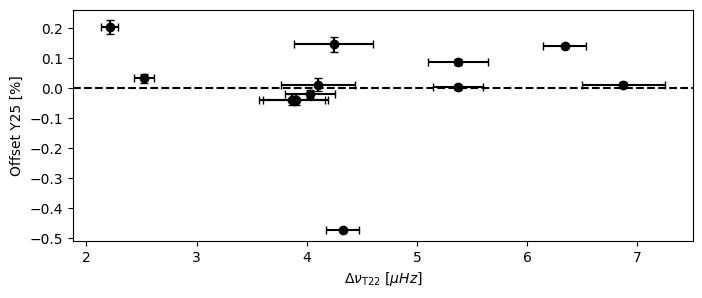

In [32]:
fig = plt.figure(figsize = (8, 3))
ax = plt.gca()
plt.errorbar(YT['dnu'], (YT['Delta_nu'] - YT['dnu'])/YT['dnu'], yerr = err_ratio_dnu, xerr = YT['ednu'], fmt = 'o', color = 'black', capsize = 3)
plt.axhline(0, color = 'black', linestyle = '--')
ax.set_xlabel(r'$\Delta \nu_{\mathrm{T22}}$ [$\mu Hz$]')
ax.set_ylabel('Offset Y25 [%]')
fig.savefig('../../figs/Y25-dnu-versus-T22-dnu.png', bbox_inches = 'tight', dpi = 150)

In [56]:
M22 = pd.read_csv('../../data/M22-with-abundances.csv')
pbjam = pd.read_csv('../../data/pbjam-results-dnu-numax-maddy-all.csv')

M22 = M22.merge(pbjam, on = 'star_id')

M22 = M22[~(M22['Quality_flag'] == 'MD')].reset_index()

[]

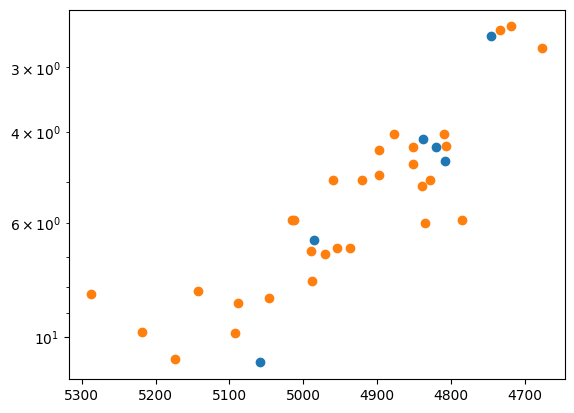

In [59]:
ax = plt.gca()
plt.scatter(M22[30:]['Teff_final'], M22[30:]['dnu_pbjam'])
plt.scatter(M22[:30]['Teff_final'], M22[:30]['dnu_pbjam'])
ax.invert_yaxis()
ax.invert_xaxis()
plt.semilogy()

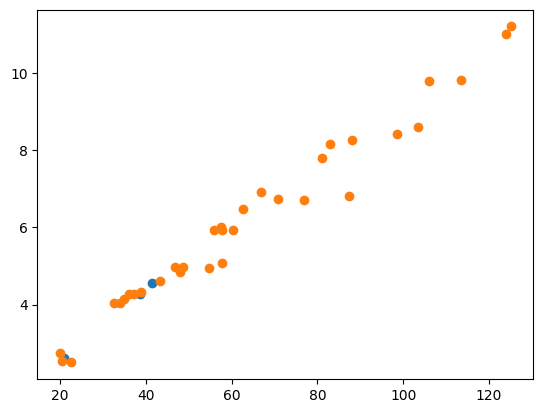

In [58]:
plt.scatter(M22[33:]['numax_pbjam'], M22[33:]['dnu_pbjam'])
plt.scatter(M22[:33]['numax_pbjam'], M22[:33]['dnu_pbjam'])

(array([7., 8., 5., 3., 5., 1., 1., 0., 1., 2.]),
 array([14.99, 20.88, 26.77, 32.66, 38.55, 44.44, 50.33, 56.22, 62.11,
        68.  , 73.89]),
 <BarContainer object of 10 artists>)

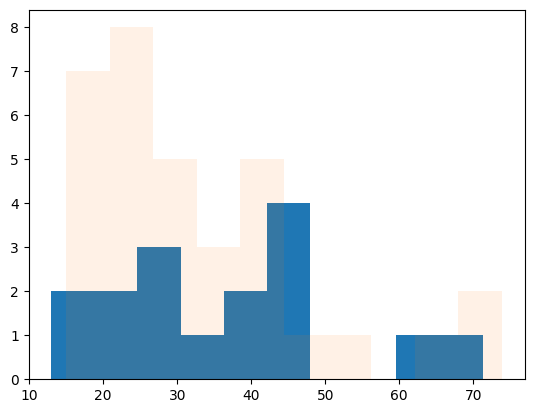

In [52]:
plt.hist(M22[33:]['Lum_bol'])
plt.hist(M22[:33]['Lum_bol'], alpha = 0.1)

In [65]:
cross['Lum_bol']/cross['LPhot']

KeyError: 'LPhot'

In [67]:
cross.columns

Index(['star_id', 'dnu_pbjam', 'ednu_pbjam', 'numax_pbjam', 'enumax_pbjam',
       'evol_stage', 'Gaia_source_ID_DR3', '2MASS_ID', 'Gmag', 'Quality_flag',
       'numax_pyMon', 'numax_err_pyMon', 'Teff_final', 'Teff_err_final',
       'Lum_bol', 'Lum_bol_err_random', 'Lum_bol_err_systematic', 'Mass',
       'Mass_err_rand', 'Delta_nu', 'delta_nu_02', 'epsilon'],
      dtype='object')